In [1]:
import torch
import torch.nn as nn
from transformers import AutoModelForCausalLM, AutoTokenizer
import collections
import types
from transformers.models.qwen3_5.modeling_qwen3_5 import Qwen3_5GatedDeltaNet
import copy

/home/joshuaz/sssm-states/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
MODEL_NAME = "Qwen/Qwen3.5-4B"

In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
)

`torch_dtype` is deprecated! Use `dtype` instead!
Fetching 2 files: 100%|██████████| 2/2 [00:00<00:00, 60349.70it/s]
The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
/home/joshuaz/sssm-states/.venv/lib/python3.10/site-packages/torch/cuda/__init__.py:435: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  queued_call()
Loading weights: 100%|██████████| 426/426 [00:00<00:00, 1512.40it/s]


In [4]:
def get_post_hook(layer_name: str, cache_store):
    def post_hook(
        module, args, kwargs, output
    ):
        cache_params = copy.deepcopy(kwargs.get('cache_params', None)) if kwargs.get('cache_params', None) is not None else None
        cache_store.append(cache_params)
    return post_hook

In [6]:
cache_store = []

for name, module in model.named_modules():
    if isinstance(module, Qwen3_5GatedDeltaNet) and "30" in name:
        module.register_forward_hook(get_post_hook(name, cache_store), with_kwargs=True)

In [5]:
messages = [{"role": "user", "content": "Hi there! Who are you?"}]
text = tokenizer.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

with torch.inference_mode():
    generated_ids = model.generate(
        **model_inputs,
        do_sample=True,
        temperature=0.7,
        top_p=0.9,
        max_new_tokens=200,
    )

output_ids = generated_ids[0][len(model_inputs.input_ids[0]) :]
response = tokenizer.decode(output_ids, skip_special_tokens=True)
print(response.strip())

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


Okay, the user is asking me who I am. I should respond with my identity as Qwen3.5, the latest large language model from Alibaba Cloud. I need to mention my version number and that I'm part of the Qwen series. Keep it friendly and concise. Let me make sure not to include any technical specifications unless asked. Just a simple introduction.
</think>

Hello! I'm **Qwen3.5**, the latest large language model developed by Alibaba Cloud. I'm part of the Qwen series and designed to assist with a wide range of tasks, from answering questions and creating content to analyzing data and solving complex problems. How can I help you today? 😊


In [ ]:
#so right now, cache_store is a list of 10 recurrent states.
#each recurrent state is a tensor of shape (1, 32, 128, 128)
# (1: batch size)
# (32: linear value heads)
# (128: per-head key / state dim)
# (128: per-head value dim)


[]

In [70]:
# Generate Deltas relative to the initial state:
def generate_delta(state, state_ref):
    return [state[i] - state_ref[i] for i in range(len(state)) if state[i] is not None]


In [ ]:

#deltas shape: list of 9 lists, each cache_store[i] - cache_store[0].
#each inside list is a list of deltas, for each layer (24 total layers)
deltas = [generate_delta(cache_store[i].recurrent_states, cache_store[0].recurrent_states) for i in range(1, len(cache_store))]
torch_deltas = torch.stack([torch.stack(layer, dim=0) for layer in deltas], dim=0)
torch_deltas.shape

In [9]:
S = torch.linalg.svdvals(torch_deltas)

S

tensor([[[[[3.6983e-01, 2.5793e-03, 6.9607e-04,  ..., 1.9961e-12,
            6.4576e-13, 5.9287e-13],
           [4.6893e+00, 3.6609e-01, 2.5026e-02,  ..., 7.5926e-12,
            6.7490e-12, 5.0728e-13],
           [4.1157e-01, 2.6731e-02, 2.7644e-03,  ..., 3.9230e-12,
            2.9880e-12, 2.1638e-12],
           ...,
           [3.9377e-01, 2.5616e-03, 8.5585e-04,  ..., 3.0817e-12,
            2.9515e-12, 1.7493e-12],
           [1.2466e+00, 2.1032e-01, 3.4261e-02,  ..., 2.0347e-12,
            4.5064e-13, 1.8584e-13],
           [1.7247e+00, 7.0435e-02, 4.8609e-02,  ..., 2.2998e-12,
            2.1674e-12, 1.1817e-12]]],


         [[[7.1909e-02, 3.1562e-02, 1.1110e-03,  ..., 1.5108e-12,
            7.2665e-13, 1.7505e-13],
           [1.6340e-01, 1.1152e-02, 2.6694e-03,  ..., 1.3238e-12,
            5.9849e-13, 1.4535e-13],
           [5.1461e-02, 7.9501e-03, 6.1571e-05,  ..., 1.0423e-12,
            8.0131e-13, 1.7650e-13],
           ...,
           [1.9721e-01, 1.9123e-02, 1

In [109]:
def get_s_energy(S, n = -1):
    # passed in batched S, shape (batch, head, dim). Want to do this over dim.
    S_energy = torch.sum(S ** 2, dim=-1, keepdim=True)
    S_nume = S ** 2
    if n == -1:
        return torch.sum(S_nume, dim=-1, keepdim=True) / S_energy
    else:
        return torch.sum(S_nume[..., :n], dim=-1, keepdim=True) / S_energy

In [11]:
s_energy = get_s_energy(S, n=16)

In [12]:
s_vals = torch.flatten(s_energy)

In [3]:
import os

os_dir = "state_spectrum_sweep/experiments/mmlu_20260320_080025"
os.listdir(os_dir)

total_tensors = []
expected_shape = (39, 24, 1, 32, 1)

for file in os.listdir(os_dir):
    if file.endswith(".pt"):
        data = torch.load(os.path.join(os_dir, file))
        if data.shape != expected_shape:
            pad_size = expected_shape[0] - data.shape[0]
            padding = (0, 0, 0, 0, 0, 0, 0, 0, 0, pad_size)
            data = torch.nn.functional.pad(data, padding, mode='constant', value=-1)
        total_tensors.append(data)

all_tensors = torch.stack(total_tensors, dim=0)
all_tensors.shape

torch.Size([5194, 39, 24, 1, 32, 1])

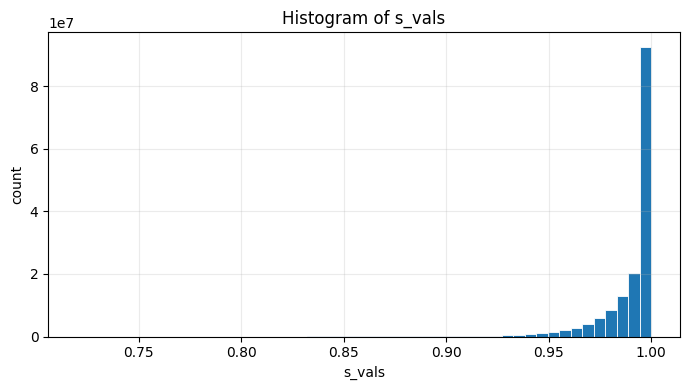

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to a flat CPU numpy array (works for torch tensors and numpy arrays)
if hasattr(all_tensors, "detach"):
    data = all_tensors.detach().float().cpu().numpy().ravel()
else:
    data = np.asarray([torch.flatten(all_tensors)]).ravel()

data = data[data >= 0]
data = data[np.isfinite(data)]

plt.figure(figsize=(7, 4))
plt.hist(data, bins=50, edgecolor="white", linewidth=0.6)
plt.title("Histogram of s_vals")
plt.xlabel("s_vals")
plt.ylabel("count")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


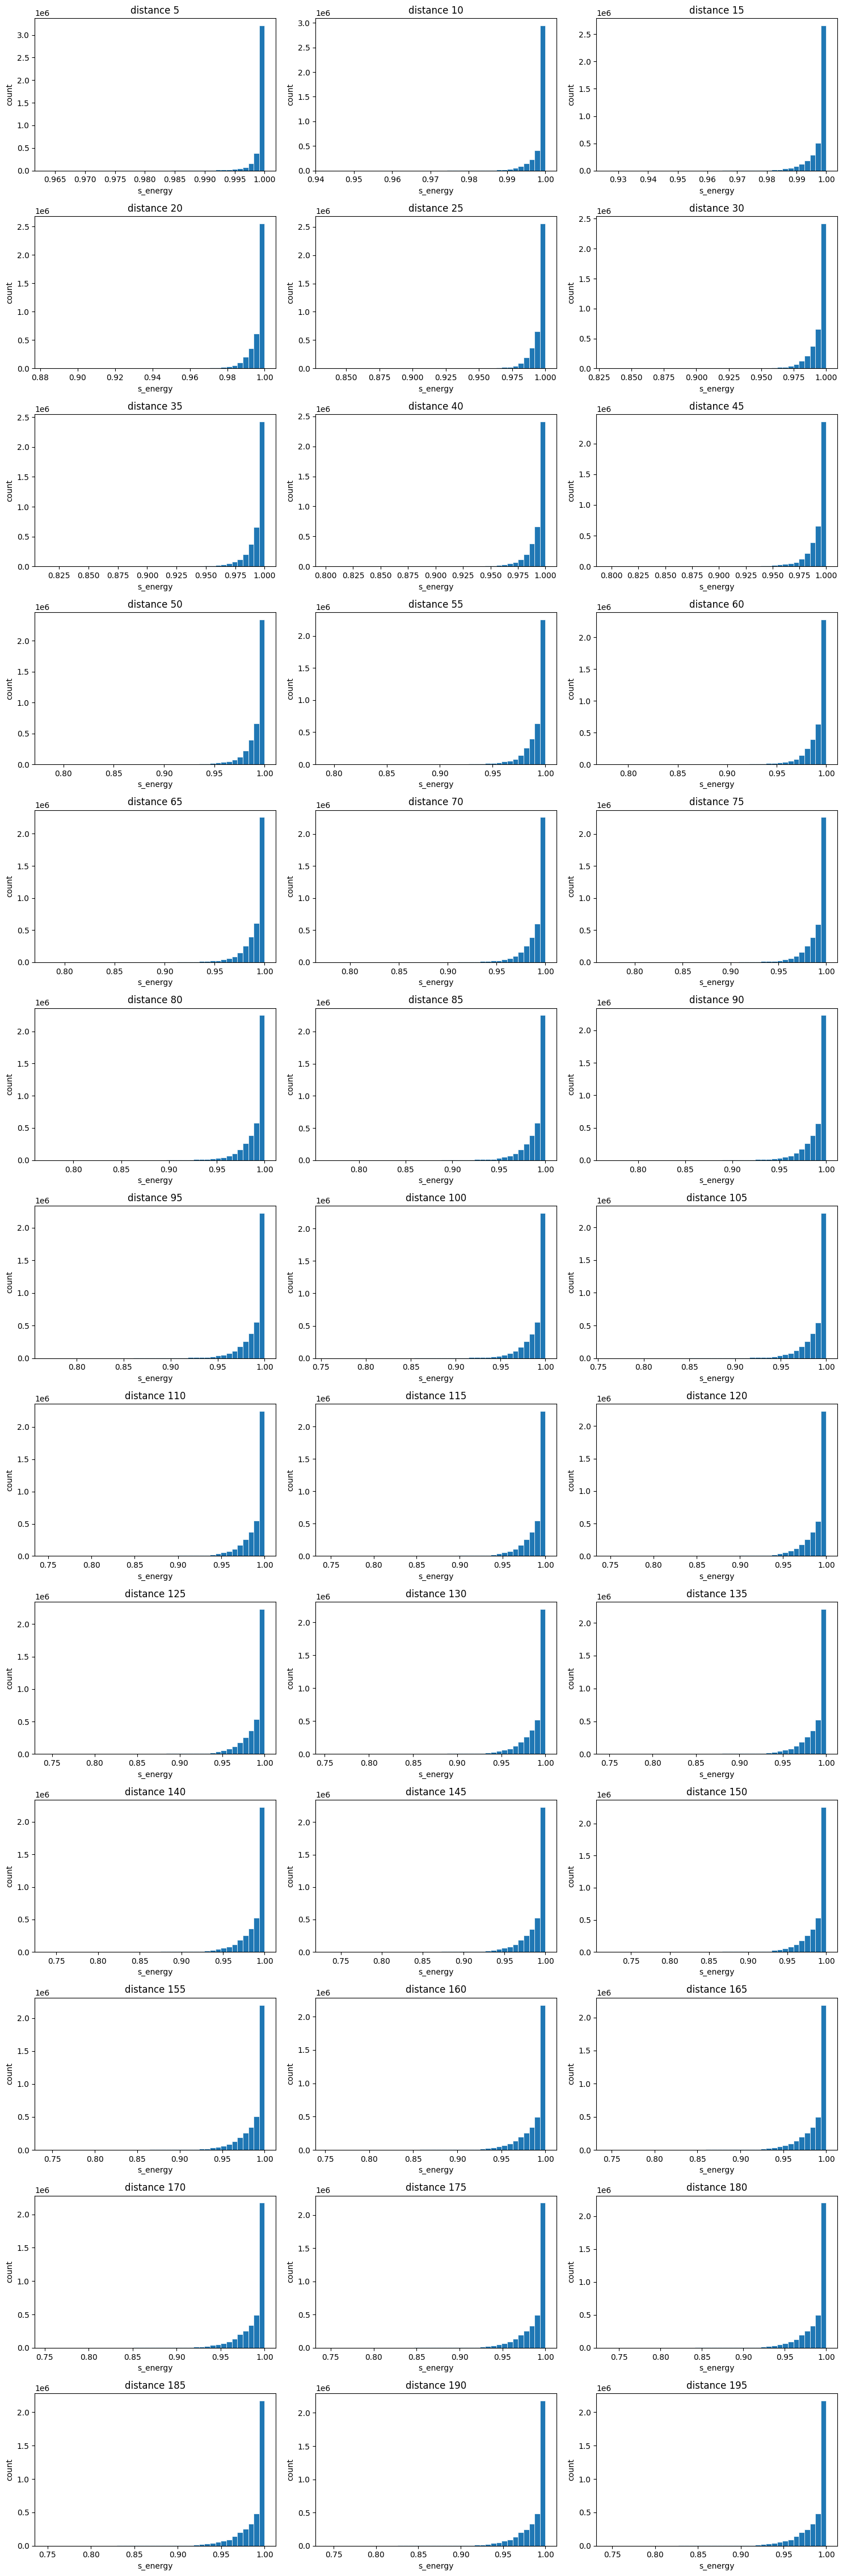

In [8]:
# Error by distance
def dist_filtered(tensor, distance):
    return tensor[:, distance : distance + 1, ...]

distances = list(range(0, all_tensors.shape[1], 1))
num_plots = len(distances)
cols = 3
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.5 * rows))
axes = np.array(axes).reshape(-1)

for ax, i in zip(axes, distances):
    vals = dist_filtered(all_tensors, i).detach().float().cpu().numpy().ravel()
    vals = vals[np.isfinite(vals)]
    vals = vals[vals >= 0]

    ax.hist(vals, bins=40, edgecolor="white", linewidth=0.5)
    ax.set_title(f"distance {(i + 1) * 5}")
    ax.set_xlabel("s_energy")
    ax.set_ylabel("count")

# Hide unused axes
for ax in axes[num_plots:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


layer 0 99th percentile: 0.9987589716911316
layer 1 99th percentile: 0.9133827090263367
layer 2 99th percentile: 0.9832688570022583
layer 3 99th percentile: 0.9709094166755676
layer 4 99th percentile: 0.9661548137664795
layer 5 99th percentile: 0.9531581401824951
layer 6 99th percentile: 0.9642102122306824
layer 7 99th percentile: 0.957966148853302
layer 8 99th percentile: 0.9566217660903931
layer 9 99th percentile: 0.9470424652099609
layer 10 99th percentile: 0.9438393115997314
layer 11 99th percentile: 0.9643692970275879
layer 12 99th percentile: 0.9634454250335693
layer 13 99th percentile: 0.9586054682731628
layer 14 99th percentile: 0.9677298069000244
layer 15 99th percentile: 0.9641367197036743
layer 16 99th percentile: 0.9590339660644531
layer 17 99th percentile: 0.9716935753822327
layer 18 99th percentile: 0.9591768980026245
layer 19 99th percentile: 0.9737593531608582
layer 20 99th percentile: 0.976831316947937
layer 21 99th percentile: 0.8899523019790649
layer 22 99th percenti

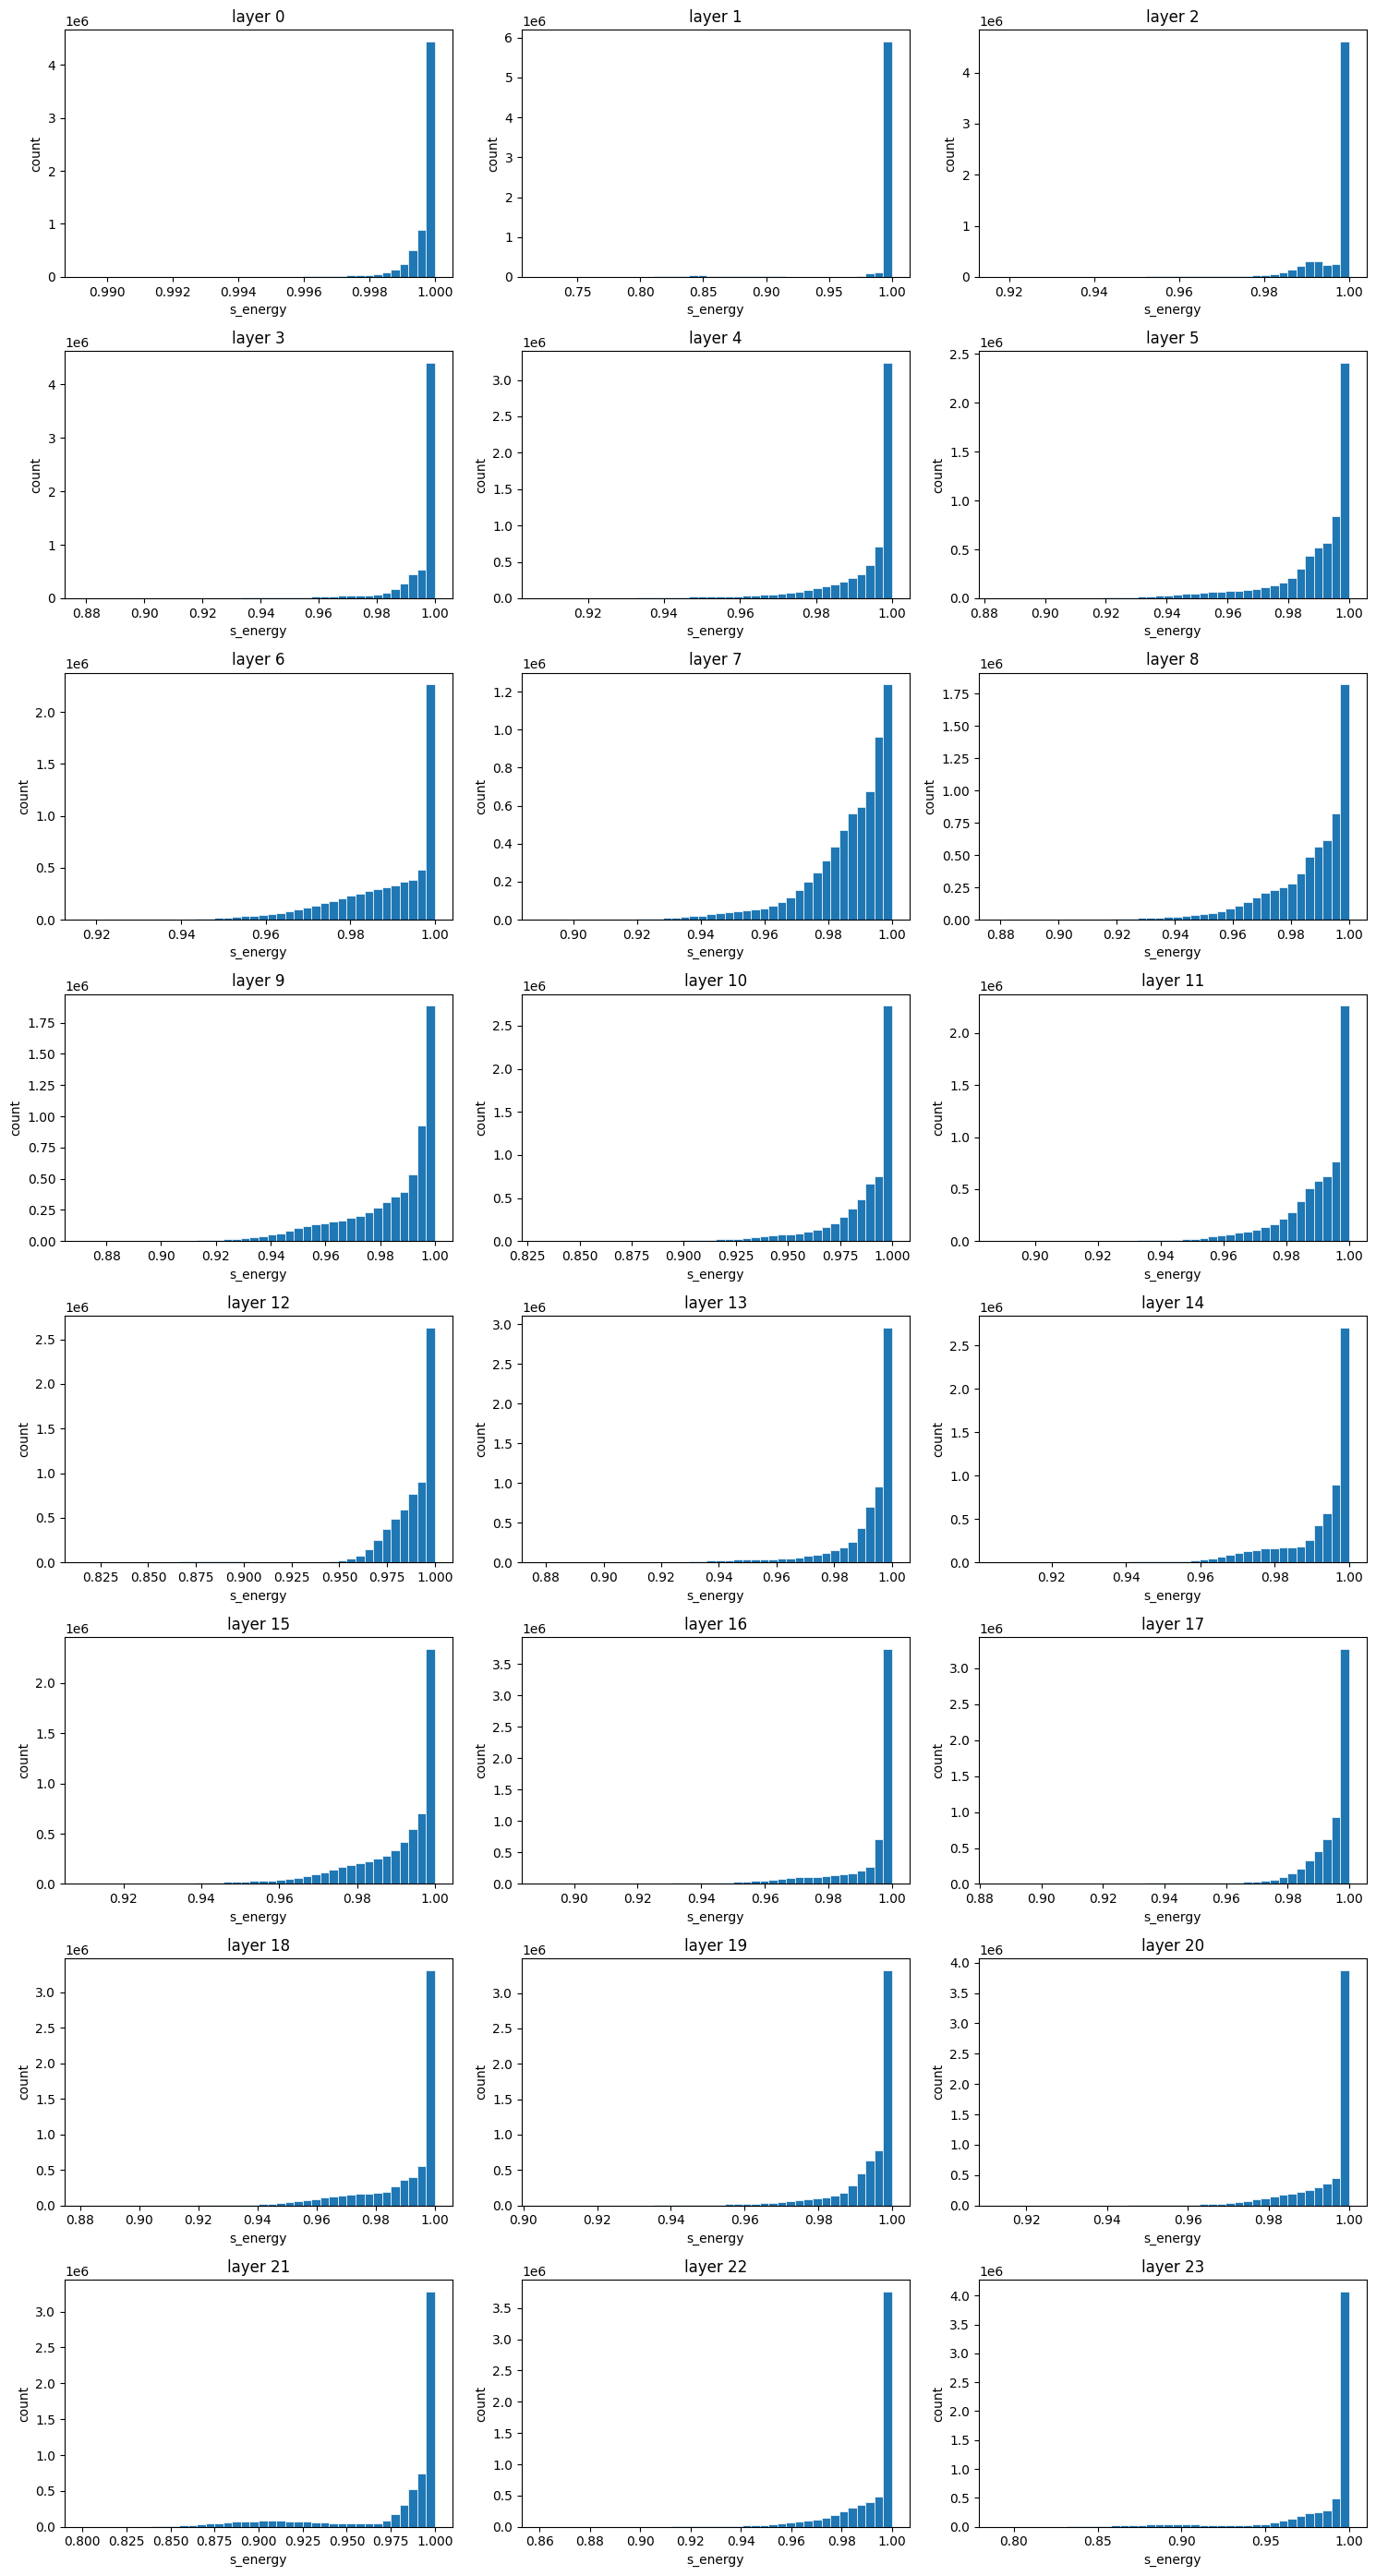

In [13]:
# Error by layer
def layer_filtered(tensor, layer):
    return tensor[:, :, layer : layer + 1, ...]


layers = list(range(0, all_tensors.shape[2]))
num_plots = len(layers)
cols = 3
rows = int(np.ceil(num_plots / cols))

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.5 * rows))
axes = np.array(axes).reshape(-1)

for ax, i in zip(axes, layers):
    vals = layer_filtered(all_tensors, i).detach().float().cpu().numpy().ravel()
    vals = vals[np.isfinite(vals)]
    vals = vals[vals >= 0]

    ax.hist(vals, bins=40, edgecolor="white", linewidth=0.5)
    ax.set_title(f"layer {i}")
    ax.set_xlabel("s_energy")
    ax.set_ylabel("count")

    # print the value at the 99th percentile of the layer (error):
    print(f"layer {i} 99th percentile: {np.percentile(vals, 5)}")
# Hide unused axes
for ax in axes[num_plots:]:
    ax.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
dist_5_s_vals = dist_filtered(all_tensors, 5).detach().float().cpu().numpy()

np.percentile(dist_5_s_vals, 1)

np.float32(0.9727315)

In [90]:
def low_percentile_indices_as_tuples(tensor, percentile=1.0):
    """Return coordinates below percentile as list[tuple]."""
    if not torch.is_tensor(tensor):
        tensor = torch.as_tensor(tensor)

    threshold = torch.quantile(tensor.float().reshape(-1), percentile / 100.0)
    idx = torch.nonzero(tensor < threshold, as_tuple=False)
    return [tuple(row.tolist()) for row in idx]

# Example:
low_indices = low_percentile_indices_as_tuples(dist_5_s_vals, 1)
len(low_indices)

231

20


## KL Divergence of a single sequence

In [ ]:
def apply_hooks(model, cache_store):
    hooks = []
    for name, module in model.named_modules():
        if isinstance(module, Qwen3_5GatedDeltaNet) and "30" in name:
            hook = module.register_forward_hook(get_post_hook(name, cache_store), with_kwargs=True)
            hooks.append(hook)
    return hooks

def remove_hooks(hooks):
    for hook in hooks:
        hook.remove()

def low_rank_svd(tensor, n=16):
    U, S, V = torch.linalg.svd(tensor, full_matrices=False)
    U, S, V = U[..., :n], S[..., :n], V[..., :n, :]

    return U @ torch.diag_embed(S) @ V

def low_rank_svd_list(lst, n=16):
    return [low_rank_svd(state, n) for state in lst]

def print_top_n_tokens(logits, n=10, tokenizer=tokenizer):
    if logits.dim() == 3:
        logits = logits[:, -1, :]   # (B, V)
    probs = torch.softmax(logits, dim=-1)
    top_probs, top_ids = torch.topk(probs, k=n, dim=-1)  # both (B, n)
    # Print first batch item
    for tok_id, p in zip(top_ids[0], top_probs[0]):
        print(f"Token: {tokenizer.decode([tok_id.item()])}, Probability: {p.item():.6f}")

# lst is a list of deltas (deltas are state differentials, in a list for the entire model)
def s_energy_divergence_list(lst, n=16):
    s_vals = [torch.linalg.svdvals(state) for state in lst]
    return [get_s_energy(s_val, n) for s_val in s_vals]


In [158]:
messages = [{"role": "user", "content": "Write a simple Python function to check if a number is prime."}]
text = tokenizer.apply_chat_template(
    messages, tokenize=False, add_generation_prompt=True
)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)
past_key_values = []
kl_divergence = []
energy_divergence = []
mse_divergence = []
with torch.inference_mode():
    out = model(**model_inputs, use_cache=True, return_dict=True)
    past_key_values = out.past_key_values

    original_state = copy.deepcopy(past_key_values)

    next_token = out.logits[:, -1:].argmax(dim=-1)
    cache_position = torch.tensor([model_inputs.input_ids.shape[1]], device=model.device, dtype=torch.long)
    print(tokenizer.decode(model_inputs.input_ids[0]) + " " + tokenizer.decode(next_token.cpu().numpy())[0])
    for i in range(10):
        out = model(
            input_ids=next_token,
            past_key_values=past_key_values,
            cache_position=cache_position,
            use_cache=True,
            return_dict=True,
        )

        deltas = generate_delta(past_key_values.recurrent_states, original_state.recurrent_states)
        low_rank_deltas = low_rank_svd_list(deltas, n=16)
        energy_divergence.append(s_energy_divergence_list(deltas, n=16))

        approximated_states = copy.deepcopy(past_key_values)
        approximated_states.recurrent_states = []
        mse_error = []
        ssm_states = 0
        for i in range(len(original_state.recurrent_states)):
            if original_state.recurrent_states[i] is not None:
                approximated_states.recurrent_states.append(original_state.recurrent_states[i] + low_rank_deltas[ssm_states])
                mse_error.append(nn.functional.mse_loss(out.past_key_values.recurrent_states[i], approximated_states.recurrent_states[i]))
                ssm_states += 1
            else:
                approximated_states.recurrent_states.append(None)

        mse_divergence.append(mse_error)
        out_approximated = model(
            input_ids=next_token,
            past_key_values=approximated_states,
            cache_position=cache_position,
            use_cache=True,
            return_dict=True,
        )

        out_log_logits = torch.log_softmax(out.logits, dim=-1)
        approx_logits = torch.log_softmax(out_approximated.logits, dim=-1)
        kl_divergence.append(nn.functional.kl_div(approx_logits, out_log_logits, reduction="batchmean", log_target=True).item())

        # greedy sampling for now
        next_token = out.logits[:, -1:].argmax(dim=-1)
        past_key_values = out.past_key_values
        cache_position = torch.tensor([model_inputs.input_ids.shape[1] + i + 1], device=model.device, dtype=torch.long)

        print(str(tokenizer.decode(next_token.cpu().numpy())) + " " + str(tokenizer.decode(out_approximated.logits[:, -1:].argmax(dim=-1).cpu().numpy())))
        print_top_n_tokens(out.logits[:, -1:], n=10)
        print("---")
        print_top_n_tokens(out_approximated.logits[:, -1:], n=10)
        print("\n-----\n")
        
# output_ids = output[0][len(model_inputs.input_ids[0]) :]
# output_text = tokenizer.decode(output_ids, skip_special_tokens=True)

<|im_start|>user
Write a simple Python function to check if a number is prime.<|im_end|>
<|im_start|>assistant
<think>
 The
[' user'] [' user']
Token:  user, Probability: 0.997070
Token:  task, Probability: 0.001673
Token:  simple, Probability: 0.000708
Token:  request, Probability: 0.000135
Token:  function, Probability: 0.000091
Token:  question, Probability: 0.000021
Token:  author, Probability: 0.000017
Token:  student, Probability: 0.000011
Token:  basic, Probability: 0.000006
Token:  simplest, Probability: 0.000005
---
Token:  user, Probability: 0.701172
Token: The, Probability: 0.118103
Token:  task, Probability: 0.037750
Token:  The, Probability: 0.020676
Token:  function, Probability: 0.015854
Token:  request, Probability: 0.007317
Token: 
, Probability: 0.005878
Token:  simple, Probability: 0.005188
Token: user, Probability: 0.004688
Token: User, Probability: 0.004578

-----

[' wants'] [' wants']
Token:  wants, Probability: 0.997070
Token:  is, Probability: 0.002632
Token:  

In [160]:
import matplotlib.pyplot as plt
import math

recurrent_states = [state for state in original_state.recurrent_states if state is not None]
print(kl_divergence)
for i in range(len(energy_divergence[0])):
    values = energy_divergence[0][i].detach().float().cpu().flatten().numpy()
    #print 1st percentile    
    print(np.percentile(values, 1))
    rmse = math.sqrt(mse_divergence[0][i].item())
    print("RMSE: ", rmse)
    print("Normalized By Range: ", rmse / (torch.max(recurrent_states[i]) - torch.min(recurrent_states[i])))
    print("Normalized By Mean: ", rmse / torch.mean(recurrent_states[i]))
    print("Normalized By Variance: ", rmse / torch.std(recurrent_states[i]))
    print("---")
    # plt.figure(figsize=(6, 4))
    # plt.hist(values, bins=10, edgecolor="black", alpha=0.8)
    # plt.title(f"Histogram of energy_divergence[0][{i}]")
    # plt.xlabel("Value")
    # plt.ylabel("Frequency")
    # plt.grid(alpha=0.2)
    # plt.show()

[0.343017578125, 0.3466796875, 0.00531005859375, 0.01360321044921875, 0.103515625, 0.0036640167236328125, 0.01229095458984375, 0.004589080810546875, 0.005222320556640625, 0.003627777099609375]
0.99999803
RMSE:  1.828982741128978e-06
Normalized By Range:  tensor(1.6607e-07, device='cuda:0')
Normalized By Mean:  tensor(0.0040, device='cuda:0')
Normalized By Variance:  tensor(4.2070e-05, device='cuda:0')
---
0.99792403
RMSE:  2.548360400070354e-06
Normalized By Range:  tensor(2.3672e-06, device='cuda:0')
Normalized By Mean:  tensor(0.0663, device='cuda:0')
Normalized By Variance:  tensor(0.0006, device='cuda:0')
---
0.99912035
RMSE:  8.596982136820397e-06
Normalized By Range:  tensor(7.7951e-06, device='cuda:0')
Normalized By Mean:  tensor(0.1651, device='cuda:0')
Normalized By Variance:  tensor(0.0022, device='cuda:0')
---
0.9995853
RMSE:  7.786869972463379e-06
Normalized By Range:  tensor(4.9413e-06, device='cuda:0')
Normalized By Mean:  tensor(0.2586, device='cuda:0')
Normalized By Var